<a href="https://colab.research.google.com/github/imid12/AI-Portfolio-Iman-Haamid/blob/main/FocusLens.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### FocusLens Project Summary

**I. Core Objective**
* **Goal:** Develop a computer vision system to monitor user engagement in real-time.
* **Target States:** Classify user status into three distinct categories:
    * **Attentive:** Eyes open, looking at the screen.
    * **Drowsy:** Eyes closed or drooping.
    * **Absent:** No face detected in the frame.

**II. Phase 1: Proof of Concept (Geometric Approach)**
* **Technique:** Implemented **MediaPipe Face Mesh** to map 468 facial landmarks.
* **Logic:** Calculated the **Eye Aspect Ratio (EAR)** using 6 specific coordinates per eye.
    * **Formula:** Used the ratio of vertical eye opening to horizontal eye width.
    * **Thresholding:** Defined `EAR < 0.21` as the cutoff for drowsiness.
* **Outcome:** Successfully detected blinks/closed eyes but required strict threshold tuning.

**III. Phase 2: Data Collection & Dataset Creation**
* **Structure:** Established a standard directory structure for Image Classification (`dataset/Attentive`, `dataset/Drowsy`, etc.).
* **Process:**
    * Automated image capture using the webcam.
    * Used the EAR logic to auto-label images during capture.
* **Refinement:** Shifted strategy to an **Eye-Only Dataset**, detecting facial landmarks to crop and save individual images of the left and right eyes (32x32 pixels), removing background noise.

**IV. Phase 3: Machine Learning (SVM Training)**
* **Model:** Trained a **Support Vector Machine (SVM)** classifier.
* **Preprocessing:**
    * Converted images to Grayscale (color is irrelevant for eye state).
    * Resized to 32x32 pixels for speed.
    * Flattened images into 1D feature vectors.
* **Training:** Split data (80% Training / 20% Testing) and saved the trained model as a `.pkl` file for instant loading.

**V. Phase 4: Production Hybrid Architecture**
* **Design:** Combined Geometric detection with Machine Learning pattern recognition for maximum robustness.
* **The Pipeline:**
    1.  **Detection (MediaPipe):** Check for face presence.
        * *If No Face:* **Status = Absent** (Logic stops here).
    2.  **Extraction:** If face exists, use landmarks to crop left and right eye regions.
    3.  **Inference (SVM):** Feed cropped eye pixels to the AI model.
    4.  **Decision Logic:**
        * *If Both Eyes == Drowsy:* **Status = Drowsy**.
        * *Else:* **Status = Attentive**.

**VI. Future Implementation (Linux Local)**
* **Migration:** Move code from Google Colab (Cloud) to local Linux machine.
* **Optimization:** Replace the Colab-specific JavaScript camera bridge with native OpenCV (`cv2.VideoCapture(0)`).
* **Application:** Run as a background service to log engagement levels during trading or study sessions.

In [ ]:
# Setup the environment
!pip install dlib opencv-python matplotlib numpy scipy mediapipe

INFO: pip is looking at multiple versions of mediapipe to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 28.7 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.13.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.8 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.8 which is incompatible.


# Using the Dlib predictor with OpenCV Haar

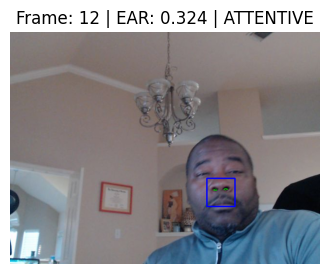

Captured Frame 12 - ATTENTIVE

✅ Session Complete.
    Frame   Time    EAR     Status
0       0   0.99  0.275  ATTENTIVE
1       1   2.07  0.309  ATTENTIVE
2       2   3.18  0.311  ATTENTIVE
3       3   4.42  0.321  ATTENTIVE
4       4   5.58  0.366  ATTENTIVE
5       5   6.66  0.221  ATTENTIVE
6       6   7.75  0.219  ATTENTIVE
7       7   8.99  0.322  ATTENTIVE
8       8  10.35  0.275  ATTENTIVE
9       9  11.46  0.233  ATTENTIVE
10     10  12.55  0.206     DROWSY
11     11  13.99  0.186     DROWSY
12     12  15.15  0.324  ATTENTIVE


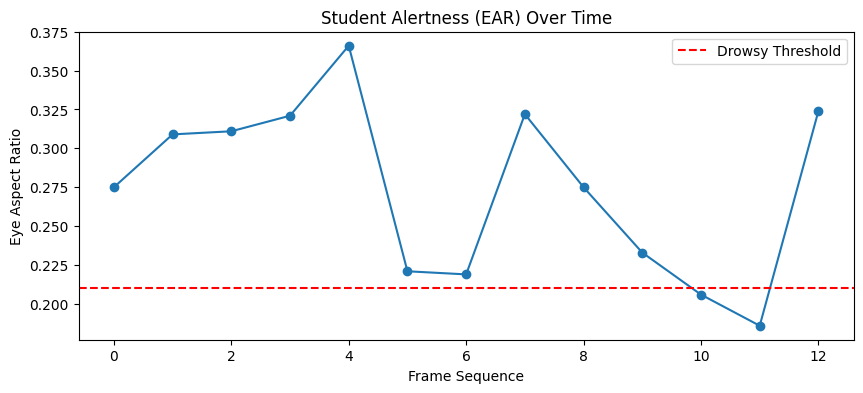

In [ ]:
from IPython.display import display, Javascript, clear_output
from google.colab.output import eval_js
from base64 import b64decode
import numpy as np
import cv2
import dlib
from scipy.spatial import distance as dist
import matplotlib.pyplot as plt
import time
import pandas as pd

# --- 1. SETUP & CONSTANTS ---
# Define the Dlib tools
# We are replacing dlib.get_frontal_face_detector() with OpenCV

# Download the necessary files if not already present
predictor_path = "/content/shape_predictor_68_face_landmarks.dat"
cascade_path = "/content/haarcascade_frontalface_default.xml"

import os
# Download Dlib landmark predictor
if not os.path.exists(predictor_path):
    print("Downloading shape_predictor_68_face_landmarks.dat...")
    !wget -q http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
    !bunzip2 shape_predictor_68_face_landmarks.dat.bz2
    !mv shape_predictor_68_face_landmarks.dat /content/
    print("Dlib landmark predictor download complete.")

# Download OpenCV Haar Cascade XML
if not os.path.exists(cascade_path):
    print("Downloading haarcascade_frontalface_default.xml...")
    # Using a common source for the cascade XML file
    !wget -q https://raw.githubusercontent.com/opencv/opencv/4.x/data/haarcascades/haarcascade_frontalface_default.xml
    !mv haarcascade_frontalface_default.xml /content/
    print("Haar Cascade XML download complete.")

# Initialize the Dlib landmark predictor
predictor = dlib.shape_predictor(predictor_path)

# Initialize the OpenCV Haar Cascade face detector
face_cascade = cv2.CascadeClassifier(cascade_path)

# EAR Function (Remains the same)
def eye_aspect_ratio(eye):
    A = dist.euclidean(eye[1], eye[5])
    B = dist.euclidean(eye[2], eye[4])
    C = dist.euclidean(eye[0], eye[3])
    # The EAR formula: (vertical distances) / (2 * horizontal distance)
    return (A + B) / (2.0 * C)

# JavaScript for Webcam Snapshot (Remains the same)
def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize output
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Capture instantly (no button click needed for loop)
      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename

# --- 2. MAIN EXECUTION LOOP ---
log_data = []
max_seconds = 15  # Run for 15 seconds
start_time = time.time()
frameCount = 0

print(f"🚀 Starting Capture for {max_seconds} seconds using OpenCV Face Detection...")

try:
    while (time.time() - start_time) < max_seconds:
        # A. Capture
        filename = take_photo()

        # B. Process
        img = cv2.imread(filename)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # *** MODIFICATION: Use OpenCV Haar Cascade for detection ***
        # faces is a list of bounding boxes (x, y, w, h)
        faces_rects = face_cascade.detectMultiScale(
            gray,
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(30, 30),
            flags=cv2.CASCADE_SCALE_IMAGE
        )

        ear_value = 0.0
        status = "No Face"

        # C. Analyze
        # Dlib's predictor requires a dlib rect object, so we convert the first detected box
        if len(faces_rects) > 0:
            # Use the largest detected face (or just the first one)
            (x, y, w, h) = faces_rects[0]
            # Convert OpenCV bounding box to a dlib rectangle object
            rect = dlib.rectangle(int(x), int(y), int(x + w), int(y + h))

            # Apply Dlib landmark prediction to the detected face rectangle
            shape = predictor(gray, rect)

            # Convert dlib shape object to a NumPy array of (x, y) coordinates
            coords = np.zeros((68, 2), dtype="int")
            for i in range(0, 68):
                coords[i] = (shape.part(i).x, shape.part(i).y)

            # Extract eye coordinates
            leftEye = coords[42:48]
            rightEye = coords[36:42]

            # Calculate EAR
            ear_value = (eye_aspect_ratio(leftEye) + eye_aspect_ratio(rightEye)) / 2.0

            # Draw eyes and bounding box on image for visualization
            leftEyeHull = cv2.convexHull(leftEye)
            rightEyeHull = cv2.convexHull(rightEye)
            cv2.drawContours(img, [leftEyeHull], -1, (0, 255, 0), 1)
            cv2.drawContours(img, [rightEyeHull], -1, (0, 255, 0), 1)
            cv2.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 2) # Draw face box

            if ear_value < 0.21:
                status = "DROWSY"
            else:
                status = "ATTENTIVE"

        # D. Log
        log_data.append({
            "Frame": frameCount,
            "Time": round(time.time() - start_time, 2),
            "EAR": round(ear_value, 3),
            "Status": status
        })

        # E. Live Feedback
        clear_output(wait=True)
        # Show image
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(4,4))
        plt.imshow(img_rgb)
        plt.title(f"Frame: {frameCount} | EAR: {ear_value:.3f} | {status}")
        plt.axis('off')
        plt.show()

        print(f"Captured Frame {frameCount} - {status}")

        # Increment counter
        frameCount += 1

except Exception as e:
    print(f"An error occurred: {e}")

# --- 3. RESULTS ---
print("\n✅ Session Complete.")
if log_data:
    df = pd.DataFrame(log_data)
    print(df)

    # Simple Plot
    plt.figure(figsize=(10, 4))
    plt.plot(df['Frame'], df['EAR'], marker='o')
    plt.axhline(0.21, color='red', linestyle='--', label='Drowsy Threshold')
    plt.title("Student Alertness (EAR) Over Time")
    plt.xlabel("Frame Sequence")
    plt.ylabel("Eye Aspect Ratio")
    plt.legend()
    plt.show()

# Trying out python library face_recognition

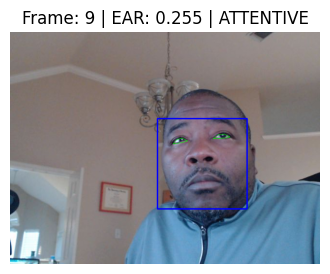

Captured Frame 9 - ATTENTIVE

✅ Session Complete.
   Frame   Time    EAR     Status
0      0   1.33  0.245  ATTENTIVE
1      1   2.85  0.263  ATTENTIVE
2      2   4.12  0.000    No Face
3      3   5.69  0.114     DROWSY
4      4   7.33  0.105     DROWSY
5      5   8.77  0.275  ATTENTIVE
6      6  10.28  0.098     DROWSY
7      7  12.28  0.104     DROWSY
8      8  13.55  0.000    No Face
9      9  15.14  0.255  ATTENTIVE


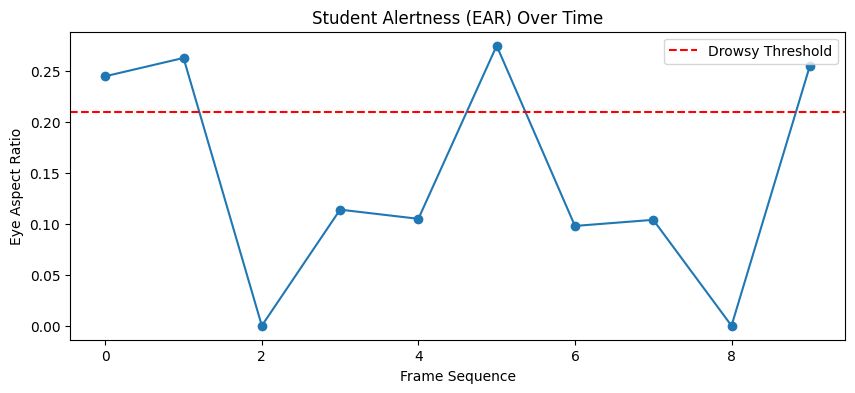

In [ ]:
from IPython.display import display, Javascript, clear_output
from google.colab.output import eval_js
from base64 import b64decode
import numpy as np
import cv2
import dlib
from scipy.spatial import distance as dist
import matplotlib.pyplot as plt
import time
import pandas as pd

# Install face_recognition if not already installed
try:
    import face_recognition
except ImportError:
    print("Installing face_recognition...")
    !pip install face_recognition
    import face_recognition

# --- 1. SETUP & CONSTANTS ---
# NOTE: We no longer need to explicitly download the dlib predictor,
# as face_recognition handles it internally.

# EAR Function (Remains the same)
def eye_aspect_ratio(eye):
    # Calculate the Euclidean distances for the two vertical eye landmarks
    A = dist.euclidean(eye[1], eye[5])
    B = dist.euclidean(eye[2], eye[4])
    # Calculate the Euclidean distance for the horizontal eye landmarks
    C = dist.euclidean(eye[0], eye[3])

    # Compute the Eye Aspect Ratio (EAR)
    return (A + B) / (2.0 * C)

# JavaScript for Webcam Snapshot (Remains the same)
def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize output
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Capture instantly (no button click needed for loop)
      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename

# --- 2. MAIN EXECUTION LOOP ---
log_data = []
max_seconds = 15  # Run for 15 seconds
start_time = time.time()
frameCount = 0
EAR_THRESHOLD = 0.21

print(f"🚀 Starting Capture for {max_seconds} seconds using face_recognition...")

try:
    while (time.time() - start_time) < max_seconds:
        # A. Capture
        filename = take_photo()

        # B. Process
        img = cv2.imread(filename)
        # face_recognition works best with RGB images
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        ear_value = 0.0
        status = "No Face"

        # C. Analyze - Use face_recognition for detection and landmarks
        # Returns a list of dictionaries, one for each face found
        face_landmarks_list = face_recognition.face_landmarks(img_rgb)

        if len(face_landmarks_list) > 0:
            # We assume only one face (the first one found)
            landmarks = face_landmarks_list[0]

            # The keys are 'left_eye' and 'right_eye', and values are lists of (x, y) tuples
            leftEye_coords = landmarks['left_eye']
            rightEye_coords = landmarks['right_eye']

            # Convert coordinate lists to NumPy arrays for distance calculation
            leftEye = np.array(leftEye_coords)
            rightEye = np.array(rightEye_coords)

            # Calculate average EAR
            ear_value = (eye_aspect_ratio(leftEye) + eye_aspect_ratio(rightEye)) / 2.0

            # Draw contours on the original BGR image for visualization
            leftEyeHull = cv2.convexHull(leftEye)
            rightEyeHull = cv2.convexHull(rightEye)
            cv2.drawContours(img, [leftEyeHull], -1, (0, 255, 0), 1)
            cv2.drawContours(img, [rightEyeHull], -1, (0, 255, 0), 1)

            # Get face bounding box from face_recognition
            # face_locations returns a list of (top, right, bottom, left) tuples
            face_locations = face_recognition.face_locations(img_rgb)
            if len(face_locations) > 0:
                top, right, bottom, left = face_locations[0]
                cv2.rectangle(img, (left, top), (right, bottom), (255, 0, 0), 2)

            if ear_value < EAR_THRESHOLD:
                status = "DROWSY"
            else:
                status = "ATTENTIVE"

        # D. Log
        log_data.append({
            "Frame": frameCount,
            "Time": round(time.time() - start_time, 2),
            "EAR": round(ear_value, 3),
            "Status": status
        })

        # E. Live Feedback
        clear_output(wait=True)
        # Show image
        img_rgb_display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(4,4))
        plt.imshow(img_rgb_display)
        plt.title(f"Frame: {frameCount} | EAR: {ear_value:.3f} | {status}")
        plt.axis('off')
        plt.show()

        print(f"Captured Frame {frameCount} - {status}")

        # Increment counter
        frameCount += 1

except Exception as e:
    print(f"An error occurred: {e}")

# --- 3. RESULTS ---
print("\n✅ Session Complete.")
if log_data:
    df = pd.DataFrame(log_data)
    print(df)

    # Simple Plot
    plt.figure(figsize=(10, 4))
    plt.plot(df['Frame'], df['EAR'], marker='o')
    plt.axhline(EAR_THRESHOLD, color='red', linestyle='--', label='Drowsy Threshold')
    plt.title("Student Alertness (EAR) Over Time")
    plt.xlabel("Frame Sequence")
    plt.ylabel("Eye Aspect Ratio")
    plt.legend()
    plt.show()

# Working with MediaPipe

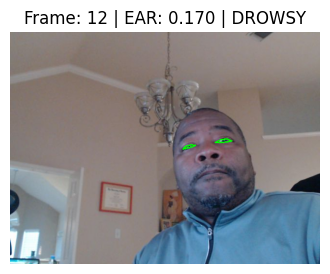

Captured Frame 12 - DROWSY

✅ Session Complete.
    Frame   Time    EAR     Status
0       0   1.00  0.232  ATTENTIVE
1       1   2.09  0.232  ATTENTIVE
2       2   3.41  0.037     DROWSY
3       3   5.01  0.125     DROWSY
4       4   6.15  0.139     DROWSY
5       5   7.25  0.190     DROWSY
6       6   8.34  0.046     DROWSY
7       7   9.53  0.274  ATTENTIVE
8       8  10.75  0.334  ATTENTIVE
9       9  12.22  0.290  ATTENTIVE
10     10  13.35  0.280  ATTENTIVE
11     11  14.61  0.253  ATTENTIVE
12     12  15.97  0.170     DROWSY


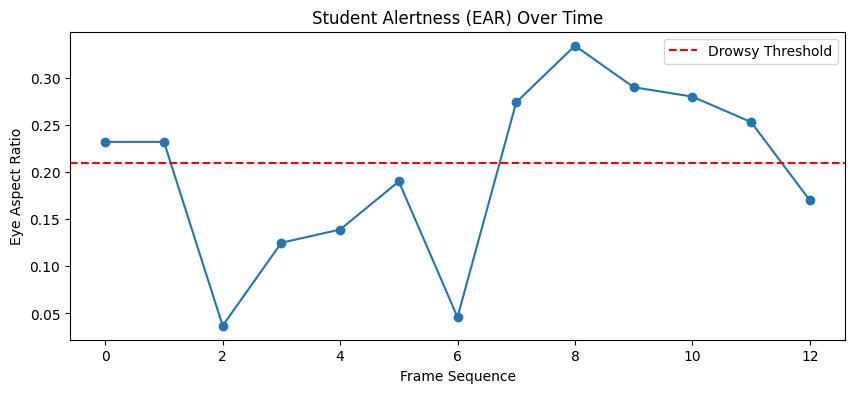

In [ ]:
from IPython.display import display, Javascript, clear_output
from google.colab.output import eval_js
from base64 import b64decode
import numpy as np
import cv2
from scipy.spatial import distance as dist
import matplotlib.pyplot as plt
import time
import pandas as pd
# Import MediaPipe and its drawing utilities
import mediapipe as mp

# Initialize MediaPipe Face Mesh
mp_face_mesh = mp.solutions.face_mesh
# Initialize the drawing utilities for visualization
mp_drawing = mp.solutions.drawing_utils

# --- 1. SETUP & CONSTANTS ---
# Landmark indices for the eyes in the MediaPipe 468-point model
# These indices form a standard 6-point pattern for the left and right eyes.
# Source: Empirical testing based on the MediaPipe face mesh topology.

# Right Eye (Viewer's right, subject's left)
# p1, p2, p3, p4, p5, p6
RIGHT_EYE_INDICES = [33, 160, 158, 133, 153, 144]
# Left Eye (Viewer's left, subject's right)
# p1, p2, p3, p4, p5, p6
LEFT_EYE_INDICES = [362, 385, 387, 263, 373, 380]

EAR_THRESHOLD = 0.21

# EAR Function (Remains the same, but uses a list of 6 points)
def eye_aspect_ratio(eye):
    # eye is a list or numpy array of 6 (x, y) coordinates
    # Vertical distances
    A = dist.euclidean(eye[1], eye[5])
    B = dist.euclidean(eye[2], eye[4])
    # Horizontal distance
    C = dist.euclidean(eye[0], eye[3])

    return (A + B) / (2.0 * C)

# JavaScript for Webcam Snapshot (Remains the same)
def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize output
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Capture instantly (no button click needed for loop)
      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename

# --- 2. MAIN EXECUTION LOOP ---
log_data = []
max_seconds = 15  # Run for 15 seconds
start_time = time.time()
frameCount = 0

print(f"🚀 Starting Capture for {max_seconds} seconds using MediaPipe Face Mesh...")

# Context manager for the Face Mesh model is best practice
with mp_face_mesh.FaceMesh(
    max_num_faces=1,
    refine_landmarks=True, # Optional: provides more accurate mouth/eye landmarks
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5) as face_mesh:

    try:
        while (time.time() - start_time) < max_seconds:
            # A. Capture
            filename = take_photo()

            # B. Process
            img = cv2.imread(filename)
            # MediaPipe requires RGB input and better performance with read-only flag
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img_rgb.flags.writeable = False

            ear_value = 0.0
            #status = "No Face"
            status = "Absent"

            # C. Analyze - Deep Learning Inference
            results = face_mesh.process(img_rgb)

            # Reset writeable flag for visualization
            img.flags.writeable = True

            # Check if landmarks were detected
            if results.multi_face_landmarks:
                # Use the first detected face
                face_landmarks = results.multi_face_landmarks[0]

                # Get image dimensions for scaling landmarks
                img_h, img_w, _ = img.shape

                # Extract the 6 required (x, y) coordinates for EAR
                def get_coords(indices):
                    points = []
                    for i in indices:
                        lm = face_landmarks.landmark[i]
                        # Scale normalized coordinates (0 to 1) to pixel coordinates
                        x = int(lm.x * img_w)
                        y = int(lm.y * img_h)
                        points.append((x, y))
                    return np.array(points)

                leftEye = get_coords(LEFT_EYE_INDICES)
                rightEye = get_coords(RIGHT_EYE_INDICES)

                # Calculate average EAR
                ear_value = (eye_aspect_ratio(leftEye) + eye_aspect_ratio(rightEye)) / 2.0

                # Drowsiness Check
                if ear_value < EAR_THRESHOLD:
                    status = "DROWSY"
                else:
                    status = "ATTENTIVE"

                # Draw eyes on image for visualization
                leftEyeHull = cv2.convexHull(leftEye)
                rightEyeHull = cv2.convexHull(rightEye)
                cv2.drawContours(img, [leftEyeHull], -1, (0, 255, 0), 2)
                cv2.drawContours(img, [rightEyeHull], -1, (0, 255, 0), 2)

            # D. Log
            log_data.append({
                "Frame": frameCount,
                "Time": round(time.time() - start_time, 2),
                "EAR": round(ear_value, 3),
                "Status": status
            })

            # E. Live Feedback
            clear_output(wait=True)
            # Show image (convert back to RGB for matplotlib)
            img_display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.figure(figsize=(4,4))
            plt.imshow(img_display)
            plt.title(f"Frame: {frameCount} | EAR: {ear_value:.3f} | {status}")
            plt.axis('off')
            plt.show()

            print(f"Captured Frame {frameCount} - {status}")

            # Increment counter
            frameCount += 1

    except Exception as e:
        print(f"An error occurred: {e}")

# --- 3. RESULTS ---
print("\n✅ Session Complete.")
if log_data:
    df = pd.DataFrame(log_data)
    print(df)

    # Simple Plot
    plt.figure(figsize=(10, 4))
    plt.plot(df['Frame'], df['EAR'], marker='o')
    plt.axhline(EAR_THRESHOLD, color='red', linestyle='--', label='Drowsy Threshold')
    plt.title("Student Alertness (EAR) Over Time")
    plt.xlabel("Frame Sequence")
    plt.ylabel("Eye Aspect Ratio")
    plt.legend()
    plt.show()

# Decide to go with MediaPipe

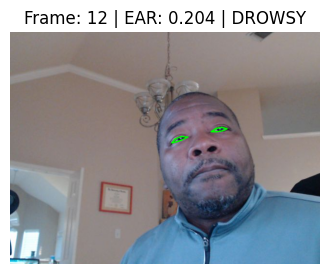

Captured Frame 12 - DROWSY

✅ Session Complete.
    Frame   Time    EAR     Status
0       0   1.03  0.233  ATTENTIVE
1       1   2.30  0.246  ATTENTIVE
2       2   3.62  0.173     DROWSY
3       3   4.74  0.033     DROWSY
4       4   5.88  0.118     DROWSY
5       5   7.13  0.165     DROWSY
6       6   8.98    NaN     Absent
7       7  10.14    NaN     Absent
8       8  11.26    NaN     Absent
9       9  12.48  0.247  ATTENTIVE
10     10  13.74  0.232  ATTENTIVE
11     11  14.86  0.210     DROWSY
12     12  16.00  0.204     DROWSY


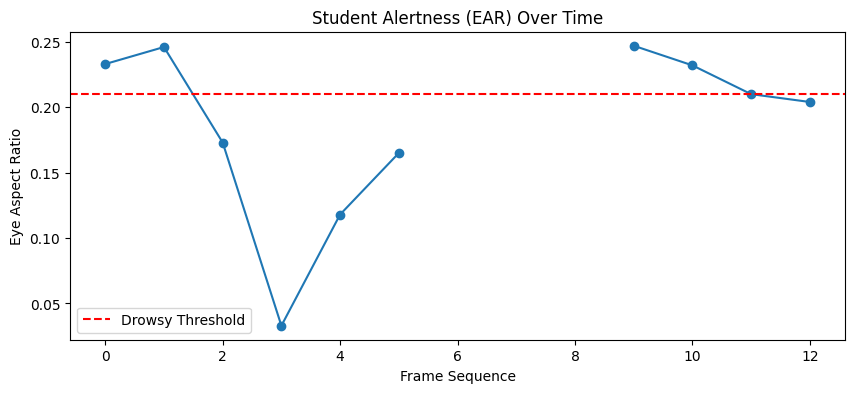

In [ ]:
# --- 2. MAIN EXECUTION LOOP (UPDATED) ---
log_data = []
max_seconds = 15  # Run for 15 seconds
start_time = time.time()
frameCount = 0

print(f"🚀 Starting Capture for {max_seconds} seconds using MediaPipe Face Mesh...")

with mp_face_mesh.FaceMesh(
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5) as face_mesh:

    try:
        while (time.time() - start_time) < max_seconds:
            # A. Capture
            filename = take_photo()

            # B. Process
            img = cv2.imread(filename)
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img_rgb.flags.writeable = False

            # --- CHANGE 1: Default to Absent ---
            # If no face is found, these values remain.
            # We use None for EAR so it doesn't mess up the graph with 0.0s
            ear_value = None
            status = "Absent"

            # C. Analyze
            results = face_mesh.process(img_rgb)

            # Reset writeable flag
            img.flags.writeable = True

            # D. Logic Tree
            if results.multi_face_landmarks:
                # Face IS detected, calculate EAR
                face_landmarks = results.multi_face_landmarks[0]
                img_h, img_w, _ = img.shape

                def get_coords(indices):
                    points = []
                    for i in indices:
                        lm = face_landmarks.landmark[i]
                        x = int(lm.x * img_w)
                        y = int(lm.y * img_h)
                        points.append((x, y))
                    return np.array(points)

                leftEye = get_coords(LEFT_EYE_INDICES)
                rightEye = get_coords(RIGHT_EYE_INDICES)

                # Calculate EAR
                ear_value = (eye_aspect_ratio(leftEye) + eye_aspect_ratio(rightEye)) / 2.0

                # Check Drowsiness
                if ear_value < EAR_THRESHOLD:
                    status = "DROWSY"
                else:
                    status = "ATTENTIVE"

                # Visualization (Draw Eyes)
                leftEyeHull = cv2.convexHull(leftEye)
                rightEyeHull = cv2.convexHull(rightEye)
                cv2.drawContours(img, [leftEyeHull], -1, (0, 255, 0), 2)
                cv2.drawContours(img, [rightEyeHull], -1, (0, 255, 0), 2)

            # E. Log
            log_data.append({
                "Frame": frameCount,
                "Time": round(time.time() - start_time, 2),
                "EAR": round(ear_value, 3) if ear_value is not None else None,
                "Status": status
            })

            # F. Live Feedback
            clear_output(wait=True)
            img_display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Add visual indicator for Absent
            if status == "Absent":
                cv2.putText(img_display, "USER ABSENT", (50, 50),
                           cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)

            plt.figure(figsize=(4,4))
            plt.imshow(img_display)

            # Handle None in title formatting
            display_ear = f"{ear_value:.3f}" if ear_value is not None else "N/A"
            plt.title(f"Frame: {frameCount} | EAR: {display_ear} | {status}")

            plt.axis('off')
            plt.show()

            print(f"Captured Frame {frameCount} - {status}")
            frameCount += 1

    except Exception as e:
        print(f"An error occurred: {e}")# --- 2. MAIN EXECUTION LOOP (UPDATED) ---
log_data = []
max_seconds = 15  # Run for 15 seconds
start_time = time.time()
frameCount = 0

print(f"🚀 Starting Capture for {max_seconds} seconds using MediaPipe Face Mesh...")

with mp_face_mesh.FaceMesh(
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5) as face_mesh:

    try:
        while (time.time() - start_time) < max_seconds:
            # A. Capture
            filename = take_photo()

            # B. Process
            img = cv2.imread(filename)
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img_rgb.flags.writeable = False

            # --- CHANGE 1: Default to Absent ---
            # If no face is found, these values remain.
            # We use None for EAR so it doesn't mess up the graph with 0.0s
            ear_value = None
            status = "Absent"

            # C. Analyze
            results = face_mesh.process(img_rgb)

            # Reset writeable flag
            img.flags.writeable = True

            # D. Logic Tree
            if results.multi_face_landmarks:
                # Face IS detected, calculate EAR
                face_landmarks = results.multi_face_landmarks[0]
                img_h, img_w, _ = img.shape

                def get_coords(indices):
                    points = []
                    for i in indices:
                        lm = face_landmarks.landmark[i]
                        x = int(lm.x * img_w)
                        y = int(lm.y * img_h)
                        points.append((x, y))
                    return np.array(points)

                leftEye = get_coords(LEFT_EYE_INDICES)
                rightEye = get_coords(RIGHT_EYE_INDICES)

                # Calculate EAR
                ear_value = (eye_aspect_ratio(leftEye) + eye_aspect_ratio(rightEye)) / 2.0

                # Check Drowsiness
                if ear_value < EAR_THRESHOLD:
                    status = "DROWSY"
                else:
                    status = "ATTENTIVE"

                # Visualization (Draw Eyes)
                leftEyeHull = cv2.convexHull(leftEye)
                rightEyeHull = cv2.convexHull(rightEye)
                cv2.drawContours(img, [leftEyeHull], -1, (0, 255, 0), 2)
                cv2.drawContours(img, [rightEyeHull], -1, (0, 255, 0), 2)

            # E. Log
            log_data.append({
                "Frame": frameCount,
                "Time": round(time.time() - start_time, 2),
                "EAR": round(ear_value, 3) if ear_value is not None else None,
                "Status": status
            })

            # F. Live Feedback
            clear_output(wait=True)
            img_display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Add visual indicator for Absent
            if status == "Absent":
                cv2.putText(img_display, "USER ABSENT", (50, 50),
                           cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)

            plt.figure(figsize=(4,4))
            plt.imshow(img_display)

            # Handle None in title formatting
            display_ear = f"{ear_value:.3f}" if ear_value is not None else "N/A"
            plt.title(f"Frame: {frameCount} | EAR: {display_ear} | {status}")

            plt.axis('off')
            plt.show()

            print(f"Captured Frame {frameCount} - {status}")
            frameCount += 1

    except Exception as e:
        print(f"An error occurred: {e}")

# --- 3. RESULTS ---
print("\n✅ Session Complete.")
if log_data:
    df = pd.DataFrame(log_data)
    print(df)

    # Simple Plot
    plt.figure(figsize=(10, 4))
    plt.plot(df['Frame'], df['EAR'], marker='o')
    plt.axhline(EAR_THRESHOLD, color='red', linestyle='--', label='Drowsy Threshold')
    plt.title("Student Alertness (EAR) Over Time")
    plt.xlabel("Frame Sequence")
    plt.ylabel("Eye Aspect Ratio")
    plt.legend()
    plt.show()

# Building out my dataset with MediaPipe using three categories:


*   Attentive
*   Drowsy
*   Absent



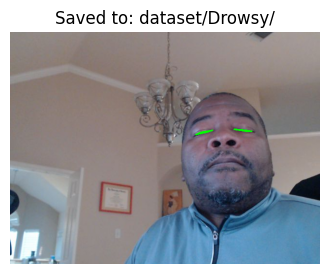


✅ Collection Complete.
Total Frames: 17
Saved CSV logs.
📦 Dataset zipped as 'my_eye_dataset.zip'. Check your files tab to download!


In [ ]:
import os
import shutil
import cv2
import time
import pandas as pd
import numpy as np
import mediapipe as mp
from IPython.display import display, Javascript, clear_output
from google.colab.output import eval_js
from base64 import b64decode
import matplotlib.pyplot as plt

# --- 1. SETUP & DIRECTORIES ---
# Define dataset path
DATASET_PATH = "dataset"
CATEGORIES = ["Attentive", "Drowsy", "Absent"]

# Clean reset: Delete existing dataset folder if it exists, then create new ones
if os.path.exists(DATASET_PATH):
    shutil.rmtree(DATASET_PATH)

for category in CATEGORIES:
    os.makedirs(os.path.join(DATASET_PATH, category), exist_ok=True)

print(f"📂 Created dataset directories in: {DATASET_PATH}/")

# Initialize MediaPipe
mp_face_mesh = mp.solutions.face_mesh
RIGHT_EYE_INDICES = [33, 160, 158, 133, 153, 144]
LEFT_EYE_INDICES = [362, 385, 387, 263, 373, 380]
EAR_THRESHOLD = 0.21

def eye_aspect_ratio(eye):
    A = dist.euclidean(eye[1], eye[5])
    B = dist.euclidean(eye[2], eye[4])
    C = dist.euclidean(eye[0], eye[3])
    return (A + B) / (2.0 * C)

# (Re-insert the take_photo function here if running in a new cell,
# otherwise it uses the one from memory)

# --- 2. DATA COLLECTION LOOP ---
log_data = []
max_seconds = 20  # Increased time for data collection
start_time = time.time()
frameCount = 0

print(f"📸 Starting Data Collection for {max_seconds} seconds...")

with mp_face_mesh.FaceMesh(
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5) as face_mesh:

    while (time.time() - start_time) < max_seconds:
        try:
            # A. Capture
            filename = take_photo()

            # Read image
            img = cv2.imread(filename)
            # Create a CLEAN copy for the dataset (no drawings!)
            clean_img = img.copy()

            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img_rgb.flags.writeable = False

            # Defaults
            ear_value = None
            status = "Absent"

            # B. Analyze
            results = face_mesh.process(img_rgb)
            img.flags.writeable = True

            if results.multi_face_landmarks:
                face_landmarks = results.multi_face_landmarks[0]
                img_h, img_w, _ = img.shape

                # Helper to get coords
                def get_coords(indices):
                    points = []
                    for i in indices:
                        lm = face_landmarks.landmark[i]
                        x = int(lm.x * img_w)
                        y = int(lm.y * img_h)
                        points.append((x, y))
                    return np.array(points)

                leftEye = get_coords(LEFT_EYE_INDICES)
                rightEye = get_coords(RIGHT_EYE_INDICES)

                ear_value = (eye_aspect_ratio(leftEye) + eye_aspect_ratio(rightEye)) / 2.0

                if ear_value < EAR_THRESHOLD:
                    status = "Drowsy"
                else:
                    status = "Attentive"

                # Visualization (Only on the display image 'img', NOT 'clean_img')
                cv2.drawContours(img, [cv2.convexHull(leftEye)], -1, (0, 255, 0), 2)
                cv2.drawContours(img, [cv2.convexHull(rightEye)], -1, (0, 255, 0), 2)

            # C. SAVE TO DATASET
            # Generate unique filename using timestamp
            timestamp = int(time.time() * 1000)
            save_path = os.path.join(DATASET_PATH, status, f"{timestamp}.jpg")

            # Save the CLEAN image
            cv2.imwrite(save_path, clean_img)

            # D. Log Metadata
            log_data.append({
                "Filename": f"{timestamp}.jpg",
                "Status": status,
                "EAR": ear_value
            })

            # E. Display Feedback
            clear_output(wait=True)
            img_display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            if status == "Absent":
                cv2.putText(img_display, "ABSENT - SAVING BG", (50, 50),
                           cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

            plt.figure(figsize=(4,4))
            plt.imshow(img_display)
            plt.title(f"Saved to: dataset/{status}/")
            plt.axis('off')
            plt.show()

            frameCount += 1

        except Exception as e:
            print(f"Error: {e}")
            break

# --- 3. EXPORT ---
print("\n✅ Collection Complete.")
print(f"Total Frames: {frameCount}")

# Save CSV map
df = pd.DataFrame(log_data)
df.to_csv(f"{DATASET_PATH}/data_log.csv", index=False)
print("Saved CSV logs.")

# Create Zip file for download
shutil.make_archive('my_eye_dataset', 'zip', DATASET_PATH)
print("📦 Dataset zipped as 'my_eye_dataset.zip'. Check your files tab to download!")

# Lets Train using SVM

🔄 Loading and preprocessing images...
✅ Loaded 17 images.
Feature Vector Shape: (17, 4096) (Images, Pixels)
Training on 13 images, Testing on 4 images...
🚀 Training SVM Classifier (this might take a moment)...
✅ Training Complete.

🎯 Model Accuracy: 25.00%

Detailed Classification Report:
              precision    recall  f1-score   support

   Attentive       0.00      0.00      0.00         3
      Drowsy       0.00      0.00      0.00         0
      Absent       1.00      1.00      1.00         1

    accuracy                           0.25         4
   macro avg       0.33      0.33      0.33         4
weighted avg       0.25      0.25      0.25         4

💾 Model saved as 'drowsiness_svm_model.pkl'


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

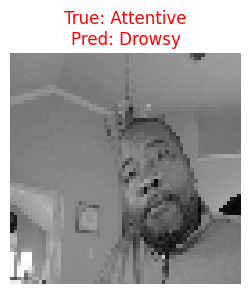

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
import joblib

# --- 1. CONFIGURATION ---
DATASET_PATH = "dataset"
CATEGORIES = ["Attentive", "Drowsy", "Absent"]
IMG_SIZE = 64  # Resize images to 64x64 to make training faster

data = []   # To hold the image pixel data
labels = [] # To hold the category labels (0, 1, 2)

print("🔄 Loading and preprocessing images...")

# --- 2. LOAD DATA ---
for category in CATEGORIES:
    path = os.path.join(DATASET_PATH, category)
    class_num = CATEGORIES.index(category)  # 0=Attentive, 1=Drowsy, 2=Absent

    # Check if directory exists
    if not os.path.exists(path):
        print(f"⚠️ Warning: Directory {path} not found. Skipping.")
        continue

    for img_name in os.listdir(path):
        try:
            # Read image in Grayscale (color isn't needed for open/closed eyes)
            img_path = os.path.join(path, img_name)
            img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            # Resize and Flatten
            # We flatten 64x64 matrix into a single 4096 vector
            new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
            flat_array = new_array.flatten()

            data.append(flat_array)
            labels.append(class_num)
        except Exception as e:
            pass

# Convert to numpy arrays
X = np.array(data)
y = np.array(labels)

print(f"✅ Loaded {len(X)} images.")
print(f"Feature Vector Shape: {X.shape} (Images, Pixels)")

# --- 3. TRAIN/TEST SPLIT ---
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training on {len(X_train)} images, Testing on {len(X_test)} images...")

# --- 4. TRAIN SVM MODEL ---
print("🚀 Training SVM Classifier (this might take a moment)...")
# C=1.0 is the regularization parameter.
# kernel='linear' usually works well for pixel data, 'rbf' is better for complex non-linear data.
model = SVC(kernel='linear', C=1.0, probability=True)
model.fit(X_train, y_train)

print("✅ Training Complete.")

# --- 5. EVALUATION ---
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"\n🎯 Model Accuracy: {accuracy * 100:.2f}%")
print("\nDetailed Classification Report:")
print(classification_report(y_test, predictions, target_names=CATEGORIES))

# --- 6. SAVE THE MODEL ---
# This saves your trained brain to a file so you can load it later without retraining
joblib.dump(model, 'drowsiness_svm_model.pkl')
print("💾 Model saved as 'drowsiness_svm_model.pkl'")

# --- 7. VISUAL TEST ---
# Let's verify with a random test image
if len(X_test) > 0:
    test_idx = np.random.randint(0, len(X_test))
    test_img_flat = X_test[test_idx]
    true_label = CATEGORIES[y_test[test_idx]]

    # Predict
    pred_label_idx = model.predict([test_img_flat])[0]
    pred_label = CATEGORIES[pred_label_idx]

    # Show
    test_img_reshaped = test_img_flat.reshape(IMG_SIZE, IMG_SIZE)
    plt.figure(figsize=(3,3))
    plt.imshow(test_img_reshaped, cmap='gray')
    plt.title(f"True: {true_label}\nPred: {pred_label}", color='green' if true_label==pred_label else 'red')
    plt.axis('off')
    plt.show()

# Testing out the Model

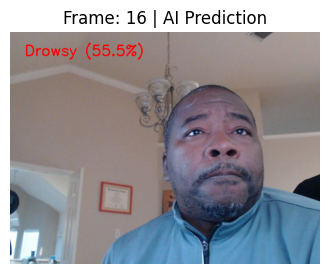

Frame 16: Drowsy (55.5%)

✅ Session Complete.


In [ ]:
import cv2
import numpy as np
import joblib
import time
from IPython.display import display, Javascript, clear_output
from google.colab.output import eval_js
from base64 import b64decode
import matplotlib.pyplot as plt

# --- 1. SETUP ---
# Load the trained model
MODEL_FILENAME = 'drowsiness_svm_model.pkl'
try:
    clf = joblib.load(MODEL_FILENAME)
    print(f"✅ Loaded model: {MODEL_FILENAME}")
except FileNotFoundError:
    print("❌ Model not found! Please run the training script first.")
    raise

CATEGORIES = ["Attentive", "Drowsy", "Absent"]
IMG_SIZE = 64  # MUST match the size used in training

# Re-define photo taking function for completeness
def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename

# --- 2. LIVE PREDICTION LOOP ---
max_seconds = 20
start_time = time.time()
frameCount = 0

print(f"🔮 Starting AI Prediction for {max_seconds} seconds...")

try:
    while (time.time() - start_time) < max_seconds:
        # A. Capture
        filename = take_photo()

        # B. Preprocess (Must match training exactly)
        img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

        # Resize to 64x64
        img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        # Flatten to 1D array (4096 features)
        flat_data = img_resized.flatten().reshape(1, -1)

        # C. Predict
        # Returns index: 0, 1, or 2
        prediction_index = clf.predict(flat_data)[0]
        prediction_label = CATEGORIES[prediction_index]

        # Get confidence (probability)
        probs = clf.predict_proba(flat_data)[0]
        confidence = probs[prediction_index]

        # D. Visualize
        clear_output(wait=True)

        # Convert original image to RGB for display
        img_display = cv2.cvtColor(cv2.imread(filename), cv2.COLOR_BGR2RGB)

        # Color code the output
        if prediction_label == "Attentive":
            color = (0, 255, 0) # Green
        elif prediction_label == "Drowsy":
            color = (255, 0, 0) # Red
        else:
            color = (0, 0, 255) # Blue (Absent)

        # Add text to image
        text = f"{prediction_label} ({confidence*100:.1f}%)"
        cv2.putText(img_display, text, (30, 50), cv2.FONT_HERSHEY_SIMPLEX,
                   1, color, 2)

        plt.figure(figsize=(4,4))
        plt.imshow(img_display)
        plt.title(f"Frame: {frameCount} | AI Prediction")
        plt.axis('off')
        plt.show()

        print(f"Frame {frameCount}: {text}")
        frameCount += 1

except Exception as e:
    print(f"Error: {e}")

print("\n✅ Session Complete.")

# Training with just the eyes.

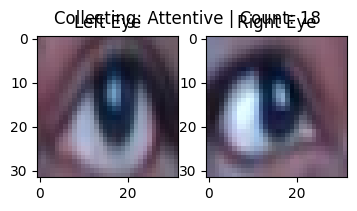

✅ Finished. Collected 18 eye images for Attentive.


In [ ]:
import os
import shutil
import cv2
import time
import numpy as np
import mediapipe as mp
from IPython.display import display, Javascript, clear_output
from google.colab.output import eval_js
from base64 import b64decode
import matplotlib.pyplot as plt

# --- 1. SETUP ---
DATASET_PATH = "dataset_eyes"
CATEGORIES = ["Attentive", "Drowsy"] # We don't need 'Absent' for the SVM anymore

# Run this once because it will delete your images in the attentive folder
# Reset Directories
#if os.path.exists(DATASET_PATH):
 #   shutil.rmtree(DATASET_PATH)
for category in CATEGORIES:
    os.makedirs(os.path.join(DATASET_PATH, category), exist_ok=True)

# MediaPipe Setup
mp_face_mesh = mp.solutions.face_mesh
# Indices for eye bounds
RIGHT_EYE_INDICES = [33, 133, 160, 144] # Corners and vertical extremes
LEFT_EYE_INDICES = [362, 263, 385, 380]

# Helper to crop eye with padding
def crop_eye(img, landmarks, indices, padding=5):
    h, w, _ = img.shape
    # Get all x and y coordinates for this eye
    x_coords = [int(landmarks[i].x * w) for i in indices]
    y_coords = [int(landmarks[i].y * h) for i in indices]

    # Calculate bounds
    min_x = max(0, min(x_coords) - padding)
    max_x = min(w, max(x_coords) + padding)
    min_y = max(0, min(y_coords) - padding)
    max_y = min(h, max(y_coords) + padding)

    # Slice the array
    cropped_eye = img[min_y:max_y, min_x:max_x]
    return cropped_eye

# Photo function (Standard)
def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename

# --- 2. COLLECTION LOOP ---
# Run this twice! Once for "Attentive" and once for "Drowsy"
# Change this variable manually before running:
CURRENT_LABEL = "Attentive"
#CURRENT_LABEL = "Drowsy"

max_seconds = 10
start_time = time.time()
count = 0

print(f"📸 Collecting data for class: {CURRENT_LABEL}")
print("Look into the camera...")

with mp_face_mesh.FaceMesh(max_num_faces=1, refine_landmarks=True) as face_mesh:
    while (time.time() - start_time) < max_seconds:
        try:
            filename = take_photo()
            img = cv2.imread(filename)
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            results = face_mesh.process(img_rgb)

            if results.multi_face_landmarks:
                lm = results.multi_face_landmarks[0].landmark

                # Crop Both Eyes
                left_crop = crop_eye(img, lm, LEFT_EYE_INDICES)
                right_crop = crop_eye(img, lm, RIGHT_EYE_INDICES)

                # Save checks (ensure crop isn't empty)
                if left_crop.size > 0 and right_crop.size > 0:
                    ts = int(time.time() * 100000)

                    # Resize to standard size for SVM (e.g., 32x32)
                    # We save them resized to save disk space and processing time
                    l_resize = cv2.resize(left_crop, (32, 32))
                    r_resize = cv2.resize(right_crop, (32, 32))

                    p1 = os.path.join(DATASET_PATH, CURRENT_LABEL, f"{ts}_L.jpg")
                    p2 = os.path.join(DATASET_PATH, CURRENT_LABEL, f"{ts}_R.jpg")

                    cv2.imwrite(p1, l_resize)
                    cv2.imwrite(p2, r_resize)
                    count += 2

                    # Visualization
                    clear_output(wait=True)
                    fig, ax = plt.subplots(1, 2, figsize=(4, 2))
                    ax[0].imshow(cv2.cvtColor(l_resize, cv2.COLOR_BGR2RGB))
                    ax[0].set_title("Left Eye")
                    ax[1].imshow(cv2.cvtColor(r_resize, cv2.COLOR_BGR2RGB))
                    ax[1].set_title("Right Eye")
                    plt.suptitle(f"Collecting: {CURRENT_LABEL} | Count: {count}")
                    plt.show()

        except Exception as e:
            print(e)
            pass

print(f"✅ Finished. Collected {count} eye images for {CURRENT_LABEL}.")

# Updating the model to use just the eyes.

In [ ]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import joblib

# --- CONFIG ---
DATASET_PATH = "dataset_eyes" # The new folder with cropped eyes
CATEGORIES = ["Attentive", "Drowsy"]
IMG_SIZE = 32 # Smaller size is faster and sufficient for eyes

data = []
labels = []

print("Reading eye images...")
for category in CATEGORIES:
    path = os.path.join(DATASET_PATH, category)
    class_num = CATEGORIES.index(category)
    if not os.path.exists(path): continue

    for img_name in os.listdir(path):
        try:
            img = cv2.imread(os.path.join(path, img_name), cv2.IMREAD_GRAYSCALE)
            if img is not None:
                # Resize to 32x32 and flatten
                resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                data.append(resized.flatten())
                labels.append(class_num)
        except Exception as e: pass

X = np.array(data)
y = np.array(labels)

# Train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = SVC(kernel='linear', C=1.0, probability=True)
print(f"Training on {len(X_train)} eye samples...")
model.fit(X_train, y_train)

# Report
acc = accuracy_score(y_test, model.predict(X_test))
print(f"✅ Eye Model Trained! Accuracy: {acc*100:.1f}%")
joblib.dump(model, 'eye_svm_model.pkl')

Reading eye images...
Training on 27 eye samples...
✅ Eye Model Trained! Accuracy: 85.7%


['eye_svm_model.pkl']

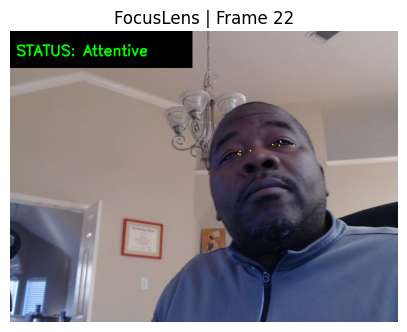

✅ Monitoring Session Complete.


In [ ]:
import cv2
import numpy as np
import joblib
import time
import mediapipe as mp
from IPython.display import display, Javascript, clear_output
from google.colab.output import eval_js
from base64 import b64decode
import matplotlib.pyplot as plt

# --- 1. CONFIGURATION ---
MODEL_FILENAME = 'eye_svm_model.pkl'
clf = joblib.load(MODEL_FILENAME)
CATEGORIES = ["Attentive", "Drowsy"]
IMG_SIZE = 32 # Must match training size

# MediaPipe Setup
mp_face_mesh = mp.solutions.face_mesh
# Indices for eye cropping (same as before)
RIGHT_EYE_INDICES = [33, 133, 160, 144]
LEFT_EYE_INDICES = [362, 263, 385, 380]

# --- 2. HELPER FUNCTIONS ---
def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename

def crop_eye_for_ai(img, landmarks, indices):
    h, w, _ = img.shape
    x_coords = [int(landmarks[i].x * w) for i in indices]
    y_coords = [int(landmarks[i].y * h) for i in indices]

    # Add padding to ensure the whole eye is captured
    padding = 10
    min_x = max(0, min(x_coords) - padding)
    max_x = min(w, max(x_coords) + padding)
    min_y = max(0, min(y_coords) - padding)
    max_y = min(h, max(y_coords) + padding)

    cropped = img[min_y:max_y, min_x:max_x]

    # Preprocess for SVM: Gray -> Resize -> Flatten
    if cropped.size == 0: return None
    gray = cv2.cvtColor(cropped, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (IMG_SIZE, IMG_SIZE))
    flat = resized.flatten().reshape(1, -1)
    return flat

# --- 3. LIVE MONITORING LOOP ---
max_seconds = 30
start_time = time.time()
frameCount = 0

print(f"👁️ Starting Hybrid Monitor (MediaPipe + SVM) for {max_seconds}s...")

with mp_face_mesh.FaceMesh(max_num_faces=1, refine_landmarks=True) as face_mesh:
    while (time.time() - start_time) < max_seconds:
        try:
            # A. Capture
            filename = take_photo()
            img = cv2.imread(filename)
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Defaults
            final_status = "Absent"
            color = (0, 0, 255) # Red for Absent
            confidence = 0.0

            # B. MediaPipe Detection
            results = face_mesh.process(img_rgb)

            if results.multi_face_landmarks:
                # Face Found! Now check eyes.
                lm = results.multi_face_landmarks[0].landmark

                # Extract Eyes
                left_data = crop_eye_for_ai(img, lm, LEFT_EYE_INDICES)
                right_data = crop_eye_for_ai(img, lm, RIGHT_EYE_INDICES)

                if left_data is not None and right_data is not None:
                    # AI Prediction
                    pred_l = clf.predict(left_data)[0] # 0=Attentive, 1=Drowsy
                    pred_r = clf.predict(right_data)[0]

                    # Logic: If BOTH eyes are Drowsy (1), then Status = Drowsy
                    # This reduces false positives from winking or glancing
                    if pred_l == 1 and pred_r == 1:
                        final_status = "Drowsy"
                        color = (255, 0, 0) # Red
                    else:
                        final_status = "Attentive"
                        color = (0, 255, 0) # Green

                # Visualization landmarks
                # (Optional: Draw small circles on eyes)
                for i in LEFT_EYE_INDICES + RIGHT_EYE_INDICES:
                    x = int(lm[i].x * img.shape[1])
                    y = int(lm[i].y * img.shape[0])
                    cv2.circle(img, (x,y), 1, (0, 255, 255), -1)

            # C. Display Output
            clear_output(wait=True)
            img_display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Status Box
            cv2.rectangle(img_display, (0,0), (300, 60), (0,0,0), -1)
            cv2.putText(img_display, f"STATUS: {final_status}", (10, 40),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

            plt.figure(figsize=(5,5))
            plt.imshow(img_display)
            plt.axis('off')
            plt.title(f"FocusLens | Frame {frameCount}")
            plt.show()

            frameCount += 1

        except Exception as e:
            print(f"Error: {e}")
            break

print("✅ Monitoring Session Complete.")